In [ ]:
# ECG Arrhythmia Classification using 1D CNN

#This notebook trains a 1D Convolutional Neural Network on the MIT-BIH Arrhythmia Dataset.

#Pipeline:
#- Load dataset
#- Handle class imbalance using oversampling
#- Build a 1D CNN
#- Train the model
#- Evaluate using a confusion matrix and classification report
#- Save the trained model


In [ ]:
"""
ECG Arrhythmia Classification - Training Script
Dataset: MIT-BIH Arrhythmia Dataset
"""

import pandas as pd
from sklearn.utils import resample
import tensorflow as tf
from tensorflow.keras import layers, models

# ---------------------------------------------------------------------
# 1. Load Dataset
# ---------------------------------------------------------------------

DATA_PATH = "/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_train.csv"

train_df = pd.read_csv(DATA_PATH, header=None)

# ---------------------------------------------------------------------
# 2. Handle Class Imbalance
# ---------------------------------------------------------------------

df_0 = train_df[train_df[187] == 0]
df_1 = train_df[train_df[187] == 1]
df_2 = train_df[train_df[187] == 2]
df_3 = train_df[train_df[187] == 3]
df_4 = train_df[train_df[187] == 4]


def upsample_class(df):
    return resample(
        df,
        replace=True,
        n_samples=20000,
        random_state=42
    )


balanced_df = pd.concat([
    df_0.sample(n=20000, random_state=42),
    upsample_class(df_1),
    upsample_class(df_2),
    upsample_class(df_3),
    upsample_class(df_4)
]).sample(frac=1, random_state=42).reset_index(drop=True)

# ---------------------------------------------------------------------
# 3. Prepare Data
# ---------------------------------------------------------------------

X = balanced_df.iloc[:, :186].values
y = balanced_df.iloc[:, 187].values

X = X.reshape((-1, 186, 1))

# ---------------------------------------------------------------------
# 4. Build 1D CNN
# ---------------------------------------------------------------------

model = models.Sequential([
    layers.Input(shape=(186, 1)),
    layers.Conv1D(64, 6, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=3, strides=2),

    layers.Conv1D(64, 3, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2, strides=2),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(5, activation="softmax")
])

# ---------------------------------------------------------------------
# 5. Compile & Train
# ---------------------------------------------------------------------

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X,
    y,
    epochs=10,
    batch_size=32,
    verbose=1
)

# ---------------------------------------------------------------------
# 6. Save Model
# ---------------------------------------------------------------------

model.save("ecg_model.h5")

print("\nTraining Complete!")
print("Model saved as ecg_model.h5")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1777907461.115868      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777907461.121877      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Starting training...
Epoch 1/20


I0000 00:00:1777907464.985634     128 service.cc:152] XLA service 0x7b72c0008b90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777907464.985681     128 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777907464.985688     128 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777907465.503162     128 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-04 15:11:07.303681: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-04 15:11:07.488706: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  27/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5529 - loss: 1.1923

I0000 00:00:1777907470.135083     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 186, 64)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 186, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 92, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 92, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 92, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 45, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 45, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 45, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 524,689 (2.00 MB)

 Trainable params: 174,597 (682.02 KB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 349,196 (1.33 MB)

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
                  precision    recall  f1-score   support

          Normal       0.94      0.96      0.95      3943
Supraventricular       0.98      0.96      0.97      3974
     Ventricular       0.99      0.98      0.99      4017
          Fusion       0.98      1.00      0.99      4075
         Unknown       1.00      0.99      0.99      3991

        accuracy                           0.98     20000
       macro avg       0.98      0.98      0.98     20000
    weighted avg       0.98      0.98      0.98     20000



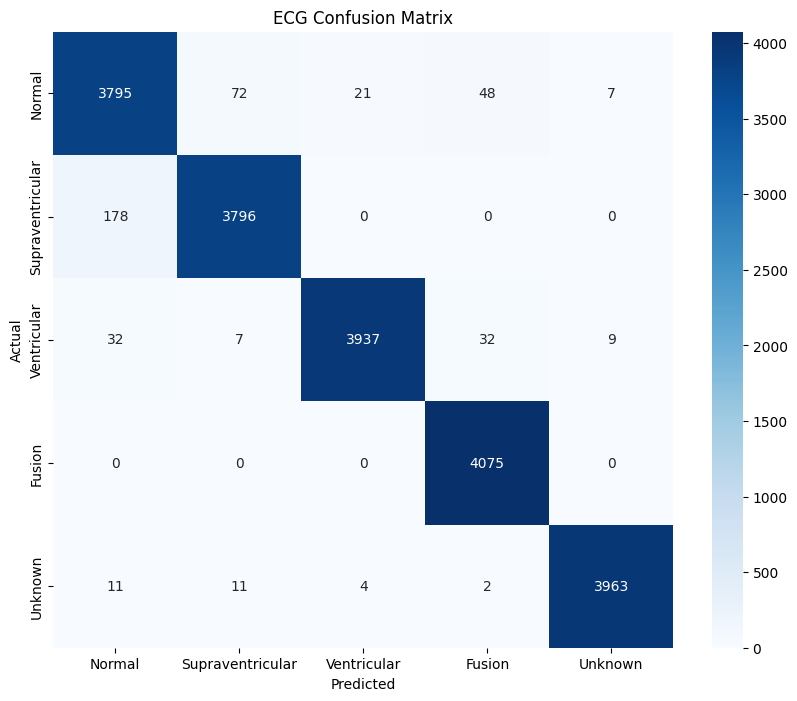

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


y_pred = np.argmax(model.predict(X_val), axis=1)

y_true = y_val 


CLASSES = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_true, y_pred, target_names=CLASSES))


cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ECG Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()